In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 DATASET 2: DYNAMIC PRICING"))

df2 = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\dynamic_pricing\dynamic_pricing.csv")

print("Shape:", df2.shape)
df2.head()

## 📊 DATASET 2: DYNAMIC PRICING

Shape: (1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [2]:
display(Markdown("### 🔍 Step 1: Data Types & Structure"))
df2.info()

### 🔍 Step 1: Data Types & Structure

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   str    
 3   Customer_Loyalty_Status  1000 non-null   str    
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   str    
 7   Vehicle_Type             1000 non-null   str    
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 78.3 KB


In [3]:
display(Markdown("### ⚠️ Step 2: Missing Values Check"))
print(df2.isnull().sum())

### ⚠️ Step 2: Missing Values Check

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64


In [4]:
display(Markdown("### 🔁 Step 3: Duplicate Check"))
print("Duplicate rows:", df2.duplicated().sum())

### 🔁 Step 3: Duplicate Check

Duplicate rows: 0


In [5]:
display(Markdown("### 📈 Step 4: Summary Statistics"))
df2.describe()

### 📈 Step 4: Summary Statistics

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


In [6]:
display(Markdown("### ✅ Step 5: Validity Checks"))
numeric_cols = df2.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    print(f"{col} -> min: {df2[col].min()}, max: {df2[col].max()}, negatives: {(df2[col] < 0).sum()}")

### ✅ Step 5: Validity Checks

Number_of_Riders -> min: 20, max: 100, negatives: 0
Number_of_Drivers -> min: 5, max: 89, negatives: 0
Number_of_Past_Rides -> min: 0, max: 100, negatives: 0
Average_Ratings -> min: 3.5, max: 5.0, negatives: 0
Expected_Ride_Duration -> min: 10, max: 180, negatives: 0
Historical_Cost_of_Ride -> min: 25.993449448411635, max: 836.1164185613576, negatives: 0


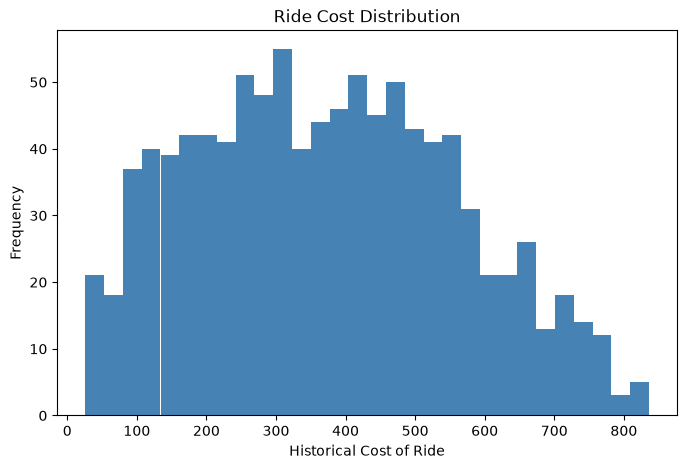

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df2['Historical_Cost_of_Ride'], bins=30, color='steelblue')
plt.title('Ride Cost Distribution')
plt.xlabel('Historical Cost of Ride')
plt.ylabel('Frequency')
plt.show()

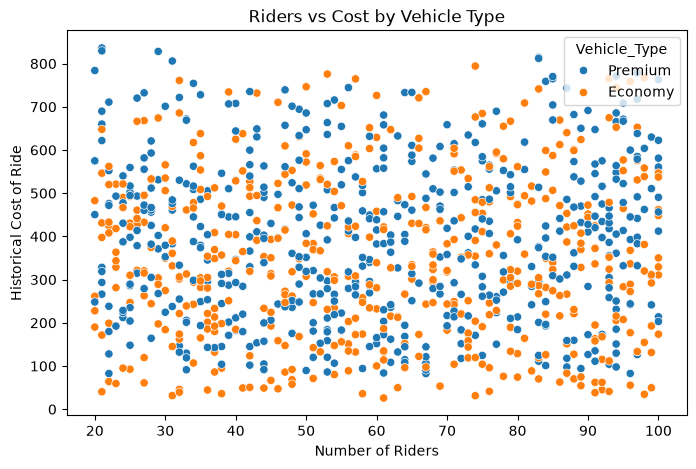

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df2, x='Number_of_Riders', y='Historical_Cost_of_Ride', hue='Vehicle_Type')
plt.title('Riders vs Cost by Vehicle Type')
plt.xlabel('Number of Riders')
plt.ylabel('Historical Cost of Ride')
plt.show()

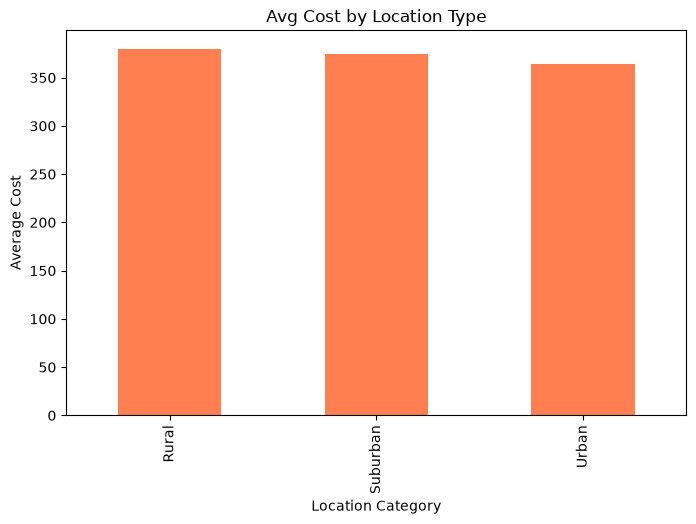

In [9]:
plt.figure(figsize=(8,5))
df2.groupby('Location_Category')['Historical_Cost_of_Ride'].mean().plot(kind='bar', color='coral')
plt.title('Avg Cost by Location Type')
plt.xlabel('Location Category')
plt.ylabel('Average Cost')
plt.show()

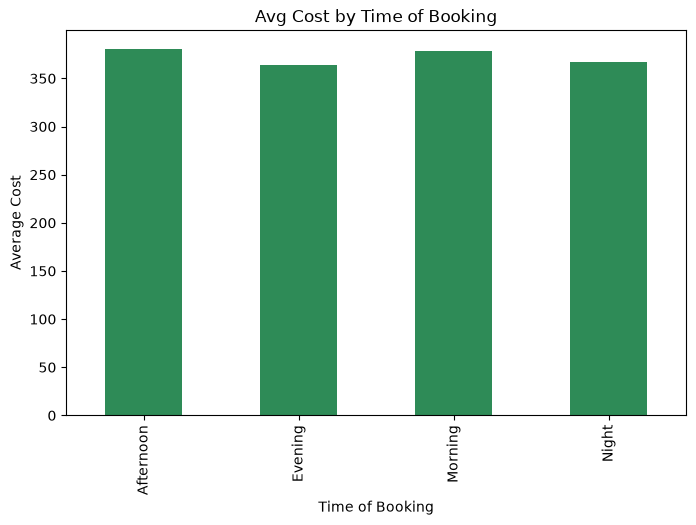

In [10]:
plt.figure(figsize=(8,5))
df2.groupby('Time_of_Booking')['Historical_Cost_of_Ride'].mean().plot(kind='bar', color='seagreen')
plt.title('Avg Cost by Time of Booking')
plt.xlabel('Time of Booking')
plt.ylabel('Average Cost')
plt.show()

### 🎨 Step 6: Visual EDA

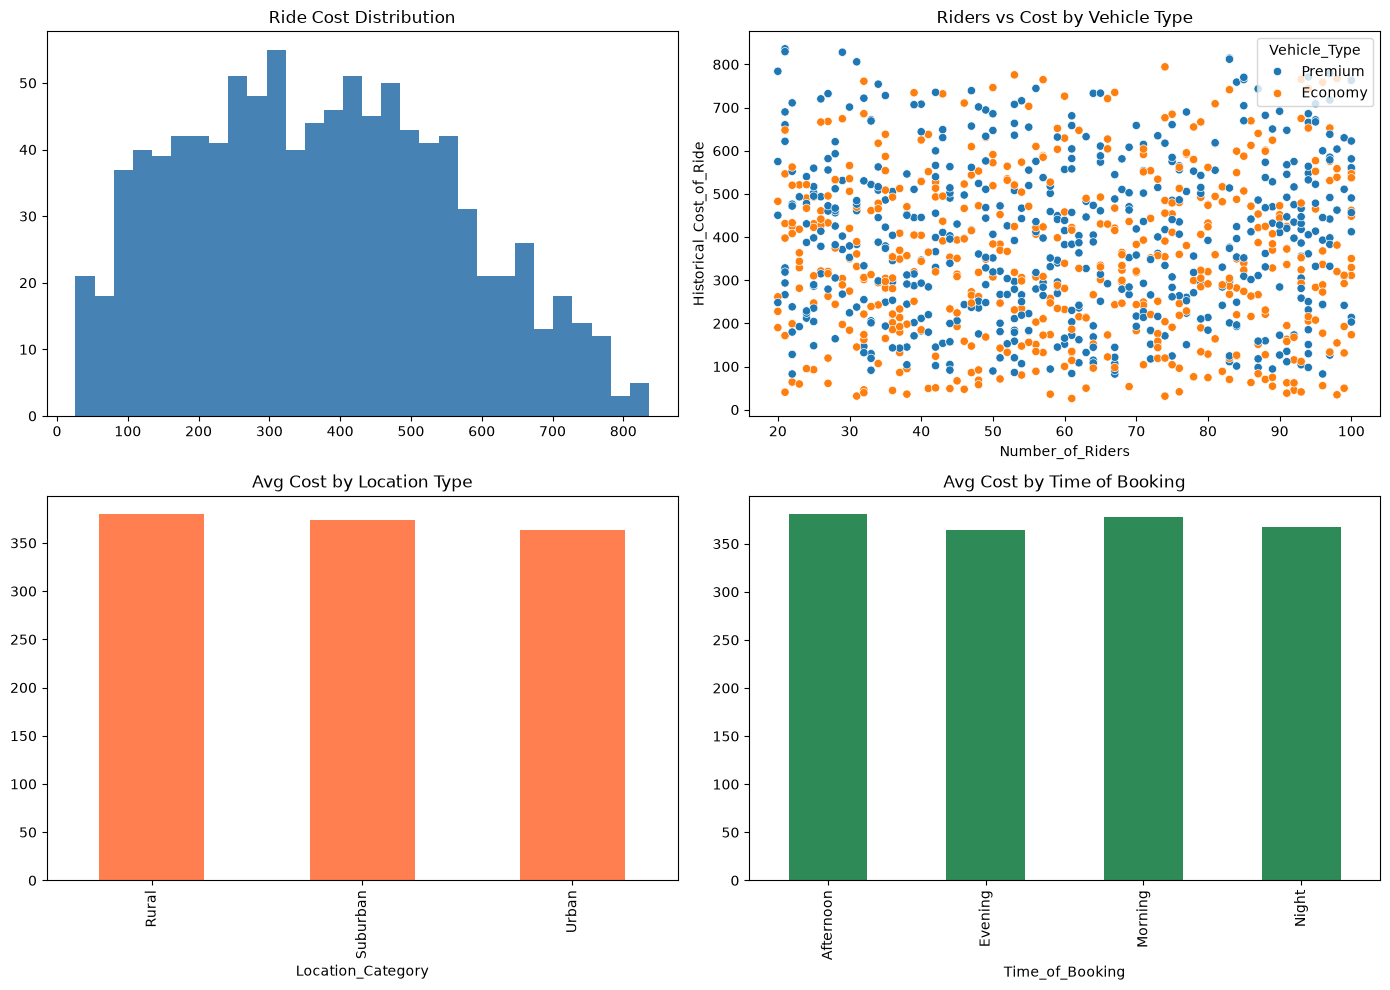

In [11]:
display(Markdown("### 🎨 Step 6: Visual EDA"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df2['Historical_Cost_of_Ride'], bins=30, color='steelblue')
axes[0,0].set_title('Ride Cost Distribution')

sns.scatterplot(data=df2, x='Number_of_Riders', y='Historical_Cost_of_Ride', hue='Vehicle_Type', ax=axes[0,1])
axes[0,1].set_title('Riders vs Cost by Vehicle Type')

df2.groupby('Location_Category')['Historical_Cost_of_Ride'].mean().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Avg Cost by Location Type')

df2.groupby('Time_of_Booking')['Historical_Cost_of_Ride'].mean().plot(kind='bar', ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Avg Cost by Time of Booking')

plt.tight_layout()
plt.show()

In [12]:
display(Markdown("### 🧹 Step 7: Data Cleaning"))

df2.columns = df2.columns.str.lower()

print("Columns standardized:", list(df2.columns))

### 🧹 Step 7: Data Cleaning

Columns standardized: ['number_of_riders', 'number_of_drivers', 'location_category', 'customer_loyalty_status', 'number_of_past_rides', 'average_ratings', 'time_of_booking', 'vehicle_type', 'expected_ride_duration', 'historical_cost_of_ride']


In [13]:
display(Markdown("### 💾 Step 8: Save Cleaned Dataset"))

df2.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\dynamic_pricing_clean.csv", index=False)

print("Saved successfully!")
print("Final shape:", df2.shape)

### 💾 Step 8: Save Cleaned Dataset

Saved successfully!
Final shape: (1000, 10)
